<a href="https://colab.research.google.com/github/kxaqw/analysis_of_borrowers_risk/blob/main/Borrower's_Risk.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Analyzing borrowers’ risk of defaulting

**Purpose of the study**

It is necessary to analyze how different client characteristics affect the fact of reducing the loan on time.
The results of the study will be taken into account when constructing a credit scoring model - a preliminary system that evaluates the ability of a guaranteed borrower to repay a loan to a bank.

**Questions to answer:**



*  Is there a relationship between the number of children and the timely repayment of a loan?

*  Is there a relationship between marital status and the timely repayment of a loan?
*   Is there a relationship between income level and the timely repayment of a loan?





**Progress of the study**

Input data from the bank — statistics on customer solvency, data.csv file.
Nothing is known about the quality of the data. Therefore, before testing the hypotheses, a data review will be needed.

We will check the data for errors and assess their impact on the study. Then, at the pre-processing stage, we will look for an opportunity to correct the most critical errors.

Thus, the study will be conducted in three stages:

*   Data review..
*   Data pre-processing.
*   Answers to questions.





# **Data overview**

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [10]:
df = pd.read_csv('credit_scoring_eng.csv') # read in the data

In [11]:
df.head(10) # use the head() method to view the first 10 rows

,children,days_employed,dob_years,education,education_id,family_status,family_status_id,gender,income_type,debt,total_income,purpose
0,1,-8437.673028,42,bachelor's degree,0,married,0,F,employee,0,40620.102,purchase of the house
1,1,-4024.803754,36,secondary education,1,married,0,F,employee,0,17932.802,car purchase
2,0,-5623.422610,33,Secondary Education,1,married,0,M,employee,0,23341.752,purchase of the house
3,3,-4124.747207,32,secondary education,1,married,0,M,employee,0,42820.568,supplementary education
4,0,340266.072047,53,secondary education,1,civil partnership,1,F,retiree,0,25378.572,to have a wedding
5,0,-926.185831,27,bachelor's degree,0,civil partnership,1,M,business,0,40922.170,purchase of the house
6,0,-2879.202052,43,bachelor's degree,0,married,0,F,business,0,38484.156,housing transactions
7,0,-152.779569,50,SECONDARY EDUCATION,1,married,0,M,employee,0,21731.829,education
8,2,-6929.865299,35,BACHELOR'S DEGREE,0,civil partnership,1,F,employee,0,15337.093,having a wedding
9,0,-2188.756445,41,secondary education,1,married,0,M,employee,0,23108.150,purchase of the house for my family


In [12]:
df.info() # get general information about data in table df

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21525 entries, 0 to 21524
Data columns (total 12 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   children          21525 non-null  int64  
 1   days_employed     19351 non-null  float64
 2   dob_years         21525 non-null  int64  
 3   education         21525 non-null  object 
 4   education_id      21525 non-null  int64  
 5   family_status     21525 non-null  object 
 6   family_status_id  21525 non-null  int64  
 7   gender            21525 non-null  object 
 8   income_type       21525 non-null  object 
 9   debt              21525 non-null  int64  
 10  total_income      19351 non-null  float64
 11  purpose           21525 non-null  object 
dtypes: float64(2), int64(5), object(5)
memory usage: 2.0+ MB


So, there are twelve columns in the table. The data types in all columns are object, float, and int.

According to the data documentation:

`children` — number of children in the family;

`days_employed` — total work experience in days;

`dob_years` — client's age in years;

`education` — client's education level;

`education_id` — education level identifier;

`family_status` — marital status;

`family_status_id` — marital status identifier;

`gender` — client's gender;

`income_type` — type of employment;

`debt` — whether the client had outstanding loan repayments;

`total_income` — monthly income;

`purpose` — purpose of obtaining the loan;

The number of values ​​in the columns varies. This means that there are missing values ​​in the data.

In [13]:
df.describe()

,children,days_employed,dob_years,education_id,family_status_id,debt,total_income
count,21525.000000,19351.000000,21525.000000,21525.000000,21525.000000,21525.000000,19351.000000
mean,0.538908,63046.497661,43.293380,0.817236,0.972544,0.080883,26787.568355
std,1.381587,140827.311974,12.574584,0.548138,1.420324,0.272661,16475.450632
min,-1.000000,-18388.949901,0.000000,0.000000,0.000000,0.000000,3306.762000
25%,0.000000,-2747.423625,33.000000,1.000000,0.000000,0.000000,16488.504500
50%,0.000000,-1203.369529,42.000000,1.000000,0.000000,0.000000,23202.870000
75%,1.000000,-291.095954,53.000000,1.000000,1.000000,0.000000,32549.611000
max,20.000000,401755.400475,75.000000,4.000000,4.000000,1.000000,362496.645000


# **Conclusion**

From the initial look at the data, we can see that days_employed and total_income has some missing data or 'NaNs'.  Now we proceed to determine the number of missing values and see what significance their absence is absence is for the dataset.

# **Data preprocessing**

**Removing duplicates**

In [14]:
df.duplicated().sum() # counting explicit duplicates

np.int64(54)

In [15]:
# removing obvious duplicates (with deleting old indexes and forming new ones)

df = df.drop_duplicates().reset_index(drop=True)
df.duplicated().sum() # checking

np.int64(0)

 Checking for unique entry of data in each column. This way, we can know at a glance which columns to fix when processing for duplicates.

In [16]:
df['education'].value_counts()

,count
education,
secondary education,13705
bachelor's degree,4710
SECONDARY EDUCATION,772
Secondary Education,711
some college,668
BACHELOR'S DEGREE,273
Bachelor's Degree,268
primary education,250
Some College,47


In [17]:
#convert all characters in the string to lower case, check the result

df['education'] = df['education'].str.lower()
df['education'].value_counts() # check

,count
education,
secondary education,15188
bachelor's degree,5251
some college,744
primary education,282
graduate degree,6


In [18]:
df['family_status'].value_counts()

,count
family_status,
married,12344
civil partnership,4163
unmarried,2810
divorced,1195
widow / widower,959


In [19]:
df['income_type'].value_counts()

,count
income_type,
employee,11091
business,5080
retiree,3837
civil servant,1457
unemployed,2
entrepreneur,2
student,1
paternity / maternity leave,1


In [20]:
df['gender'].value_counts()

,count
gender,
F,14189
M,7281
XNA,1


In [21]:
df['purpose'].value_counts()

,count
purpose,
wedding ceremony,793
having a wedding,773
to have a wedding,769
real estate transactions,675
buy commercial real estate,662
housing transactions,652
buying property for renting out,652
transactions with commercial real estate,650
housing,646


# **Categorization of loan purposes**

In [23]:
def purposes(reason):
  if 'image' in reason:
    return 'getting an education'
  if 'wedding' in reason:
    return 'holding a wedding'
  if 'car' in reason:
    return 'car transactions'
  return 'real estate transactions'

In [24]:
df['purpose_category'] = df['purpose'].apply(purposes)

# **Formation of additional dictionary dataframes, decomposition of the original dataframe**

To make the table lighter, we create two new data frames `df_educatio`n and `df_family` with the columns

`education_id` and `education` in the first;

`family_status_id`  and  `family_status` in the second.

After that, we delete the columns `education`,` family` and `puropse` from the current table.

In [25]:
df_education = df[['education_id', 'education']].drop_duplicates().reset_index(drop=True)
df_education

,education_id,education
0,0,bachelor's degree
1,1,secondary education
2,2,some college
3,3,primary education
4,4,graduate degree


In [26]:
df_family = df[['family_status_id', 'family_status']].drop_duplicates().reset_index(drop=True)
df_family

,family_status_id,family_status
0,0,married
1,1,civil partnership
2,2,widow / widower
3,3,divorced
4,4,unmarried


In [27]:
df = df.drop(['family_status','education','purpose'], axis=1)

In [28]:
df.head(10)

,children,days_employed,dob_years,education_id,family_status_id,gender,income_type,debt,total_income,purpose_category
0,1,-8437.673028,42,0,0,F,employee,0,40620.102,real estate transactions
1,1,-4024.803754,36,1,0,F,employee,0,17932.802,car transactions
2,0,-5623.422610,33,1,0,M,employee,0,23341.752,real estate transactions
3,3,-4124.747207,32,1,0,M,employee,0,42820.568,real estate transactions
4,0,340266.072047,53,1,1,F,retiree,0,25378.572,holding a wedding
5,0,-926.185831,27,0,1,M,business,0,40922.170,real estate transactions
6,0,-2879.202052,43,0,0,F,business,0,38484.156,real estate transactions
7,0,-152.779569,50,1,0,M,employee,0,21731.829,real estate transactions
8,2,-6929.865299,35,0,1,F,employee,0,15337.093,holding a wedding
9,0,-2188.756445,41,1,0,M,employee,0,23108.150,real estate transactions


# **Checking data for anomalies and corrections**

In [29]:
df = df.loc[df['gender'] != 'XNA']
df['gender'].value_counts()

,count
gender,
F,14189
M,7281


In [30]:
df['days_employed'] = df['days_employed'].abs()
df.head() #fixing that day_employed column values can be negative

,children,days_employed,dob_years,education_id,family_status_id,gender,income_type,debt,total_income,purpose_category
0,1,8437.673028,42,0,0,F,employee,0,40620.102,real estate transactions
1,1,4024.803754,36,1,0,F,employee,0,17932.802,car transactions
2,0,5623.422610,33,1,0,M,employee,0,23341.752,real estate transactions
3,3,4124.747207,32,1,0,M,employee,0,42820.568,real estate transactions
4,0,340266.072047,53,1,1,F,retiree,0,25378.572,holding a wedding


In [33]:
display(min(df['days_employed']), max(df['days_employed'])) #let's look at the minimum and maximum values ​​of work experience.

24.14163324048118

401755.40047533

401755 days is more than 1100 years of experience.

Let's look for lines where the length of service is more than 15,000 days (15,000 days is almost equivalent to 40 years of work experience)

In [34]:
df[df['days_employed'] >= 15000]['total_income'].count()

np.int64(3458)

In [35]:
df[df['days_employed'] >= 15000]['days_employed'].mean()

np.float64(363692.53684059804)

The length of service is indicated in hours, not days. Most likely, again problems related to unloading from different databases (in one, the length of service is indicated in days, in the other - in hours).

Let's try to fix this by dividing the abnormal length of service values ​​by 24 hours.

In [36]:
med_days_employed = df[df['days_employed'] <= 15000]['days_employed'].median()

In [39]:
def to_do_better(days):
    if days >= 15000:
        return med_days_employed
    else:
        return days
to_do_better(10000)


10000

In [40]:
df['days_employed'] = df['days_employed'].apply(to_do_better)
df.head(10)

,children,days_employed,dob_years,education_id,family_status_id,gender,income_type,debt,total_income,purpose_category
0,1,8437.673028,42,0,0,F,employee,0,40620.102,real estate transactions
1,1,4024.803754,36,1,0,F,employee,0,17932.802,car transactions
2,0,5623.422610,33,1,0,M,employee,0,23341.752,real estate transactions
3,3,4124.747207,32,1,0,M,employee,0,42820.568,real estate transactions
4,0,1628.635034,53,1,1,F,retiree,0,25378.572,holding a wedding
5,0,926.185831,27,0,1,M,business,0,40922.170,real estate transactions
6,0,2879.202052,43,0,0,F,business,0,38484.156,real estate transactions
7,0,152.779569,50,1,0,M,employee,0,21731.829,real estate transactions
8,2,6929.865299,35,0,1,F,employee,0,15337.093,holding a wedding
9,0,2188.756445,41,1,0,M,employee,0,23108.150,real estate transactions


Now let's check the age of the borrowers: are there any persons under 18 years of age (including zero values)? If the share of such lines is small, then we will delete them.

In [42]:
df[df['dob_years'] < 18]['dob_years'].count() / df.shape[0]

np.float64(0.004704238472286912)

In [43]:
df = df.loc[df['dob_years'] >= 18]

In [46]:
max(df['dob_years']) #let's check the maximum age of borrowers

75

Now let's check what values ​​are in the children column

In [47]:
df['children'].value_counts() #It is necessary to correct the negative number of children to zero.

,count
children,
0,14037
1,4793
2,2039
3,328
20,75
-1,47
4,41
5,9


In [48]:
df['children'] = df['children'].replace(-1, 0)

Now let's take a closer look at borrowers who have 20 children, perhaps these are private orphanages?

In [49]:
df[df['children'] == 20].head()

,children,days_employed,dob_years,education_id,family_status_id,gender,income_type,debt,total_income,purpose_category
606,20,880.221113,21,1,0,M,business,0,23253.578,real estate transactions
720,20,855.595512,44,1,0,F,business,0,18079.798,real estate transactions
1074,20,3310.411598,56,1,0,F,employee,1,36722.966,real estate transactions
2510,20,2714.161249,59,0,2,F,employee,0,42315.974,real estate transactions
3301,20,NaN,35,1,4,F,civil servant,0,NaN,real estate transactions


In [50]:
df[df['children'] == 20]['children'].count() / df.shape[0]

np.float64(0.0035097571248069634)

In [51]:
df = df.loc[df['children'] < 20]

# **Processing missing values**

In [52]:
df.isna().sum()

,0
children,0
days_employed,2101
dob_years,0
education_id,0
family_status_id,0
gender,0
income_type,0
debt,0
total_income,2101
purpose_category,0


In [54]:
df['days_employed'] = df['days_employed'].fillna(med_days_employed) #We fill the empty values ​​of the days_employed column with the previously calculated median value of length of service (med_days_employed).

In [56]:
med_total_income = df['total_income'].median()
df['total_income'] = df['total_income'].fillna(med_total_income) #same here

In [57]:
df.isna().sum()

,0
children,0
days_employed,0
dob_years,0
education_id,0
family_status_id,0
gender,0
income_type,0
debt,0
total_income,0
purpose_category,0


# **Data type replacement**

In [58]:
df['total_income'] = df['total_income'].astype('int')
df['days_employed'] = df['days_employed'].astype('int')
df.head()

,children,days_employed,dob_years,education_id,family_status_id,gender,income_type,debt,total_income,purpose_category
0,1,8437,42,0,0,F,employee,0,40620,real estate transactions
1,1,4024,36,1,0,F,employee,0,17932,car transactions
2,0,5623,33,1,0,M,employee,0,23341,real estate transactions
3,3,4124,32,1,0,M,employee,0,42820,real estate transactions
4,0,1628,53,1,1,F,retiree,0,25378,holding a wedding


# **Income categorization**

The last step of data preprocessing remains: income categorization.

Based on the ranges specified below, we will create a column total_income_category with categories:

E - 0 – 35,000 rubles;

D - 35,001 – 50,000 rubles;

C - 50,001 – 300,000 rubles;

B - 300,001 – 1,000,000 rubles;

A - 1,000,001 rubles and higher.

In [59]:
def income_total(incomes):
    if incomes <= 30000:
        return 'E'
    if incomes <= 50000:
        return 'D'
    if incomes <= 200000:
        return 'C'
    if incomes <=1000000:
        return 'B'
    return 'A'

income_total(150000)

'C'

In [60]:
df['total_income_category'] = df['total_income'].apply(income_total)

In [61]:
df.head(10)

,children,days_employed,dob_years,education_id,family_status_id,gender,income_type,debt,total_income,purpose_category,total_income_category
0,1,8437,42,0,0,F,employee,0,40620,real estate transactions,D
1,1,4024,36,1,0,F,employee,0,17932,car transactions,E
2,0,5623,33,1,0,M,employee,0,23341,real estate transactions,E
3,3,4124,32,1,0,M,employee,0,42820,real estate transactions,D
4,0,1628,53,1,1,F,retiree,0,25378,holding a wedding,E
5,0,926,27,0,1,M,business,0,40922,real estate transactions,D
6,0,2879,43,0,0,F,business,0,38484,real estate transactions,D
7,0,152,50,1,0,M,employee,0,21731,real estate transactions,E
8,2,6929,35,0,1,F,employee,0,15337,holding a wedding,E
9,0,2188,41,1,0,M,employee,0,23108,real estate transactions,E


# **Conclusion**

Preprocessing revealed three problems in the data:

data anomalies,

missing values,

duplicates - explicit and implicit.

We also categorized the data to make it easier to work with the table.
We replaced missing values ​​in quantitative data with the median.


# **Data Analyzing**

Is there a relationship between the number of children and the timely repayment of a loan?

In [63]:
children_data_pivot = df.pivot_table(index=['children'], columns='debt', values='purpose_category', aggfunc='count')

children_data_pivot =  children_data_pivot.fillna(0)
children_data_pivot = children_data_pivot.reset_index()
children_data_pivot['percent'] = (children_data_pivot[1] / (children_data_pivot[1] + children_data_pivot[0])) *100
children_data_pivot[1] = children_data_pivot[1].astype('int')
children_data_pivot[0] = children_data_pivot[0].astype('int')
children_data_pivot.sort_values('percent')

debt,children,0,1,percent
5,5,9,0,0.000000
0,0,13025,1059,7.519171
3,3,301,27,8.231707
1,1,4352,441,9.200918
2,2,1845,194,9.514468
4,4,37,4,9.756098


<ipython-input-65-b9830603603a>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='children',y='percent', data = children_data_pivot, palette='viridis')


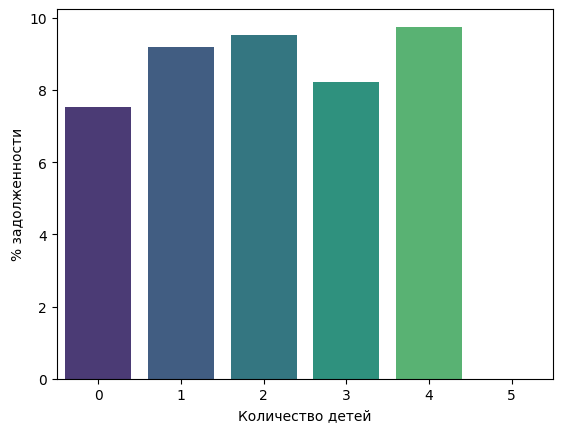

In [65]:
sns.barplot(x='children',y='percent', data = children_data_pivot, palette='viridis')
plt.xlabel('Количество детей')
plt.ylabel('% задолженности')
plt.show()

The lowest percentage of delinquencies is among childless borrowers (7.52%); in other groups this share is 1-2% higher.

Is there a relationship between marital status and repaying a loan on time?

In [66]:
family_data_pivot = df.pivot_table(index=['family_status_id'], columns='debt', values='purpose_category', aggfunc='count')
family_data_pivot['percent'] = (family_data_pivot[1] / (family_data_pivot[1] + family_data_pivot[0])) *100
family_data_pivot = family_data_pivot.merge(df_family, on='family_status_id', how='left')
family_data_pivot.sort_values('percent')

,family_status_id,0,1,percent,family_status
2,2,888,62,6.526316,widow / widower
3,3,1099,84,7.100592,divorced
0,0,11323,924,7.544705,married
1,1,3746,383,9.275854,civil partnership
4,4,2513,272,9.766607,unmarried


<ipython-input-68-d530638afb80>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='family_status',x='percent',data = family_data_pivot, palette='viridis')


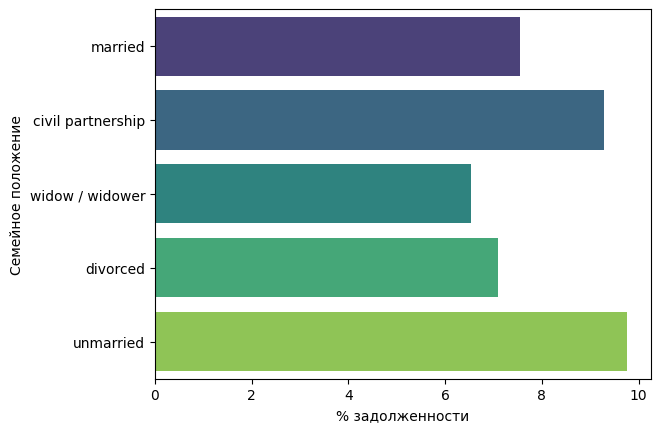

In [68]:
sns.barplot(y='family_status',x='percent',data = family_data_pivot, palette='viridis')
plt.xlabel('% задолженности')
plt.ylabel('Семейное положение')
plt.show()

The most conscientious borrowers are people who have had experience of family relationships, formalized officially (regardless of whether these relationships ended for some reason or not). The number of clients who did not have such experience and who have a loan debt is 2-3% higher.

Is there a relationship between income level and timely loan repayment?

In [69]:
income_data_pivot = df.pivot_table(index=['total_income_category'], columns='debt', values='gender', aggfunc='count')
income_data_pivot['percent'] = (income_data_pivot[1] / (income_data_pivot[1] + income_data_pivot[0])) *100
income_data_pivot = income_data_pivot.reset_index()    # сбросим мультииндексы в сводной таблице
income_data_pivot.sort_values('percent')

debt,total_income_category,0,1,percent
1,C,1214,91,6.973180
2,D,4210,341,7.492859
3,E,14135,1292,8.374927
0,B,10,1,9.090909


<ipython-input-70-3f49f3ec182b>:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y='total_income_category',x='percent',data = income_data_pivot, palette='viridis')


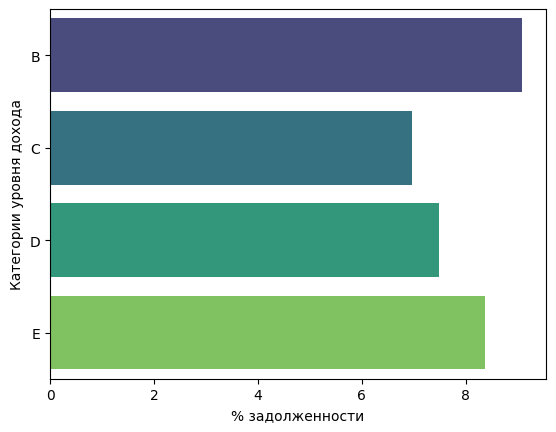

In [70]:
sns.barplot(y='total_income_category',x='percent',data = income_data_pivot, palette='viridis')
plt.xlabel('% задолженности')
plt.ylabel('Категории уровня дохода')
plt.show()

As can be seen from the table and diagram above, borrowers with an income level of 35,001 - 50,000 rubles first of all try to repay the loan according to the schedule. The percentage of delays for them is the lowest: only 6%.

Next come people with an income above average and high income (from 300,001 rubles and above).

The most defaulting borrowers are those with the lowest income level (less than 35,000 rubles.)